In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cardekho.csv')

In [3]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0


# **Data Cleaning**

In [4]:
df.shape

(8128, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [6]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [7]:
df['mileage(km/ltr/kg)'].fillna(df['mileage(km/ltr/kg)'].mean(), inplace=True)
df['engine'].fillna(df['engine'].mean(), inplace=True)
df['seats'].fillna(df['seats'].mode()[0], inplace=True)

In [8]:
df.isnull().sum().sum()

np.int64(215)

In [9]:
df['seats'] = df['seats'].astype('int32')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['max_power'].fillna(df['max_power'].median(), inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  8128 non-null   float64
 9   engine              8128 non-null   float64
 10  max_power           8128 non-null   float64
 11  seats               8128 non-null   int32  
dtypes: float64(3), int32(1), int64(3), object(5)
memory usage: 730.4+ KB


In [11]:
df.duplicated().sum()

np.int64(1202)

In [12]:
df.drop_duplicates(inplace=True)

# **Exploratory Data Analysis**

In [13]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.463912,1431.724228,87.556583,5.421600
std,4.078286,5.197670e+05,5.835810e+04,3.987884,486.048519,31.310612,0.972171
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.418783,1248.000000,81.860000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [14]:
df.shape

(6926, 12)

In [15]:
df = df[df['selling_price'] < 1.000000e+07]
df = df[df['km_driven'] < 2.360457e+06]

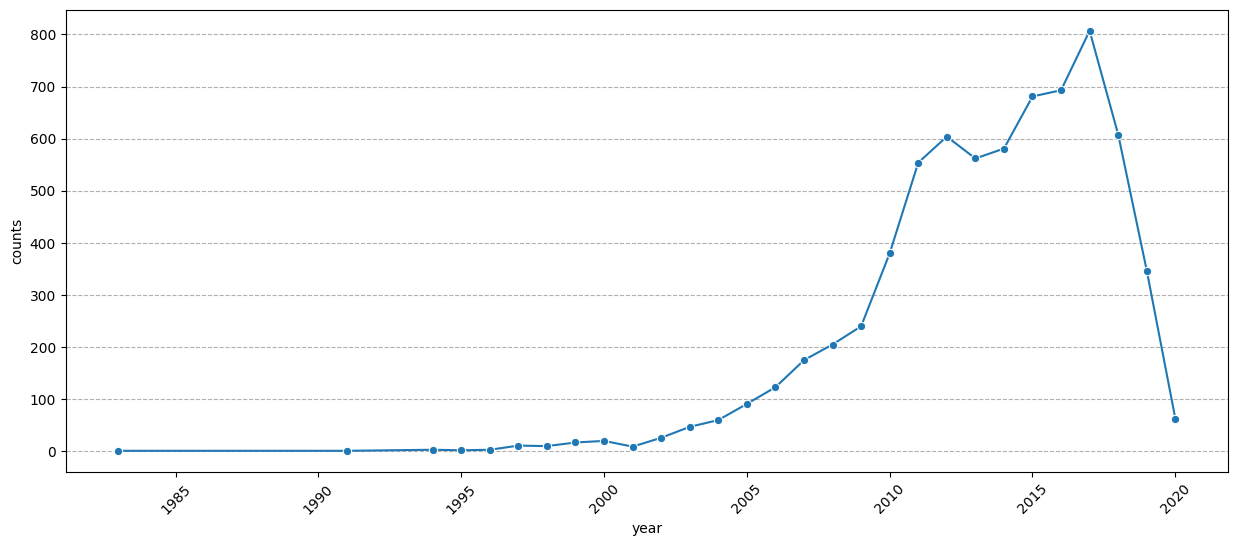

In [16]:
plt.figure(figsize=(15,6))
sns.lineplot(df['year'].value_counts().reset_index(name='counts'), x='year', y='counts', marker='o')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6924 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6924 non-null   object 
 1   year                6924 non-null   int64  
 2   selling_price       6924 non-null   int64  
 3   km_driven           6924 non-null   int64  
 4   fuel                6924 non-null   object 
 5   seller_type         6924 non-null   object 
 6   transmission        6924 non-null   object 
 7   owner               6924 non-null   object 
 8   mileage(km/ltr/kg)  6924 non-null   float64
 9   engine              6924 non-null   float64
 10  max_power           6924 non-null   float64
 11  seats               6924 non-null   int32  
dtypes: float64(3), int32(1), int64(3), object(5)
memory usage: 676.2+ KB


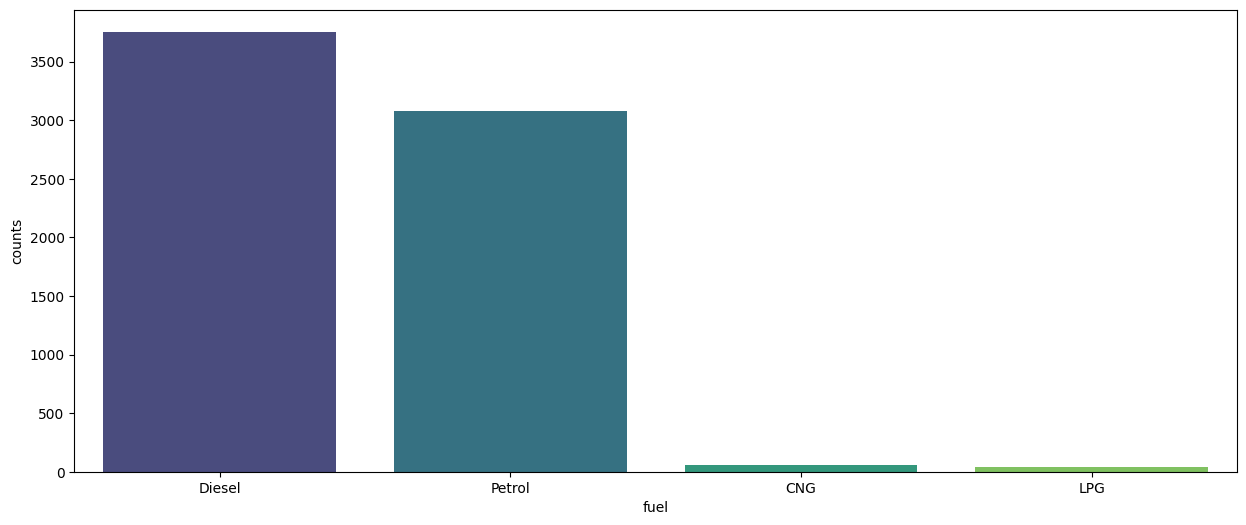

In [18]:
plt.figure(figsize=(15,6))
sns.barplot(df['fuel'].value_counts().reset_index(name='counts'), x='fuel', y='counts', palette='viridis')
plt.show()

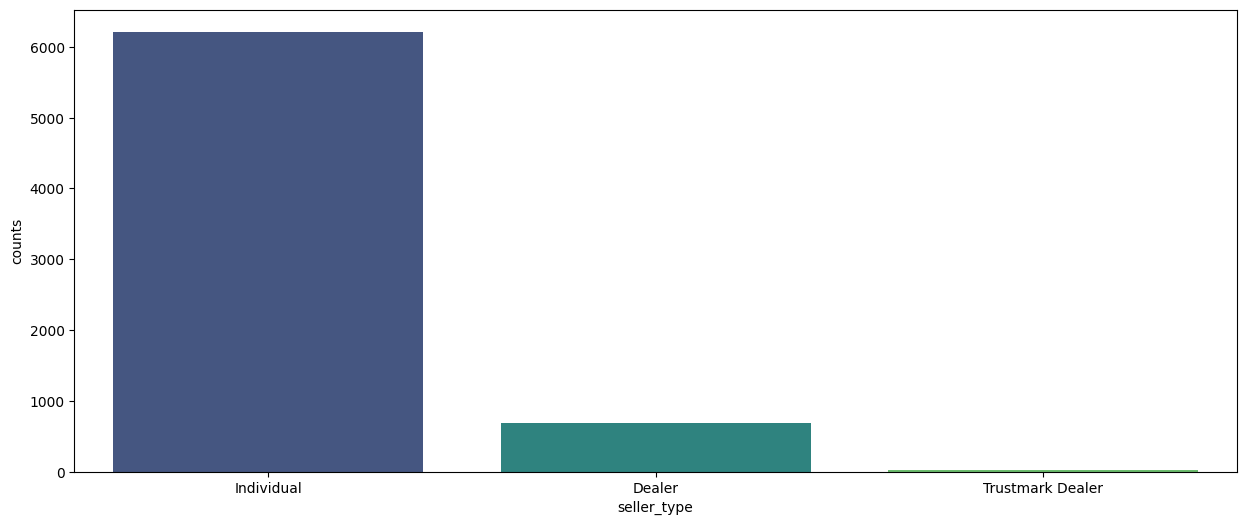

In [19]:
plt.figure(figsize=(15,6))
sns.barplot(df['seller_type'].value_counts().reset_index(name='counts'), x='seller_type', y='counts', palette='viridis')
plt.show()

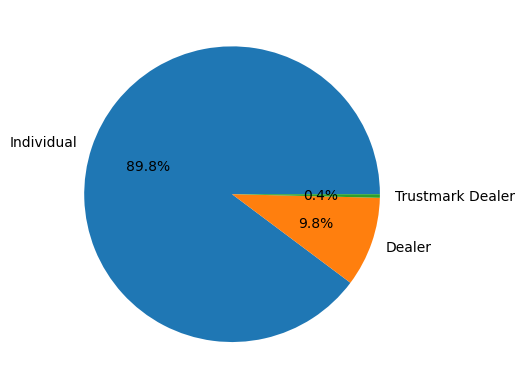

In [20]:
seller = (df['seller_type'].value_counts().reset_index(name='counts'))
plt.pie(seller['counts'], labels=seller['seller_type'], autopct='%1.1f%%')
plt.show()

# **Data Pre-Processing Technique**

In [21]:
df['brand'] = df['name'].str.split().str[0]

In [22]:
x = df.drop(['selling_price', 'name'], axis=1)
y = df['selling_price']

In [23]:
type(x)

pandas.core.frame.DataFrame

In [24]:
x.head(3)

,year,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,brand
0,2014,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5,Maruti
1,2014,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5,Skoda
2,2006,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5,Honda


In [25]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

In [26]:
ct = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', sparse_output=False),
     ['fuel', 'seller_type', 'transmission', 'brand']),
    ('ore', OrdinalEncoder(), ['owner']),
    ('mms', MinMaxScaler(),
     ['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'year'])
], remainder='passthrough')

In [27]:
x_en = ct.fit_transform(x)

In [28]:
x_en = pd.DataFrame(x_en, columns=ct.get_feature_names_out())

In [37]:
type(x_en)

pandas.core.frame.DataFrame

In [29]:
x_en.shape

(6924, 44)

In [38]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
lr.score(x_train, y_train)*100

74.51126592831649

In [41]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


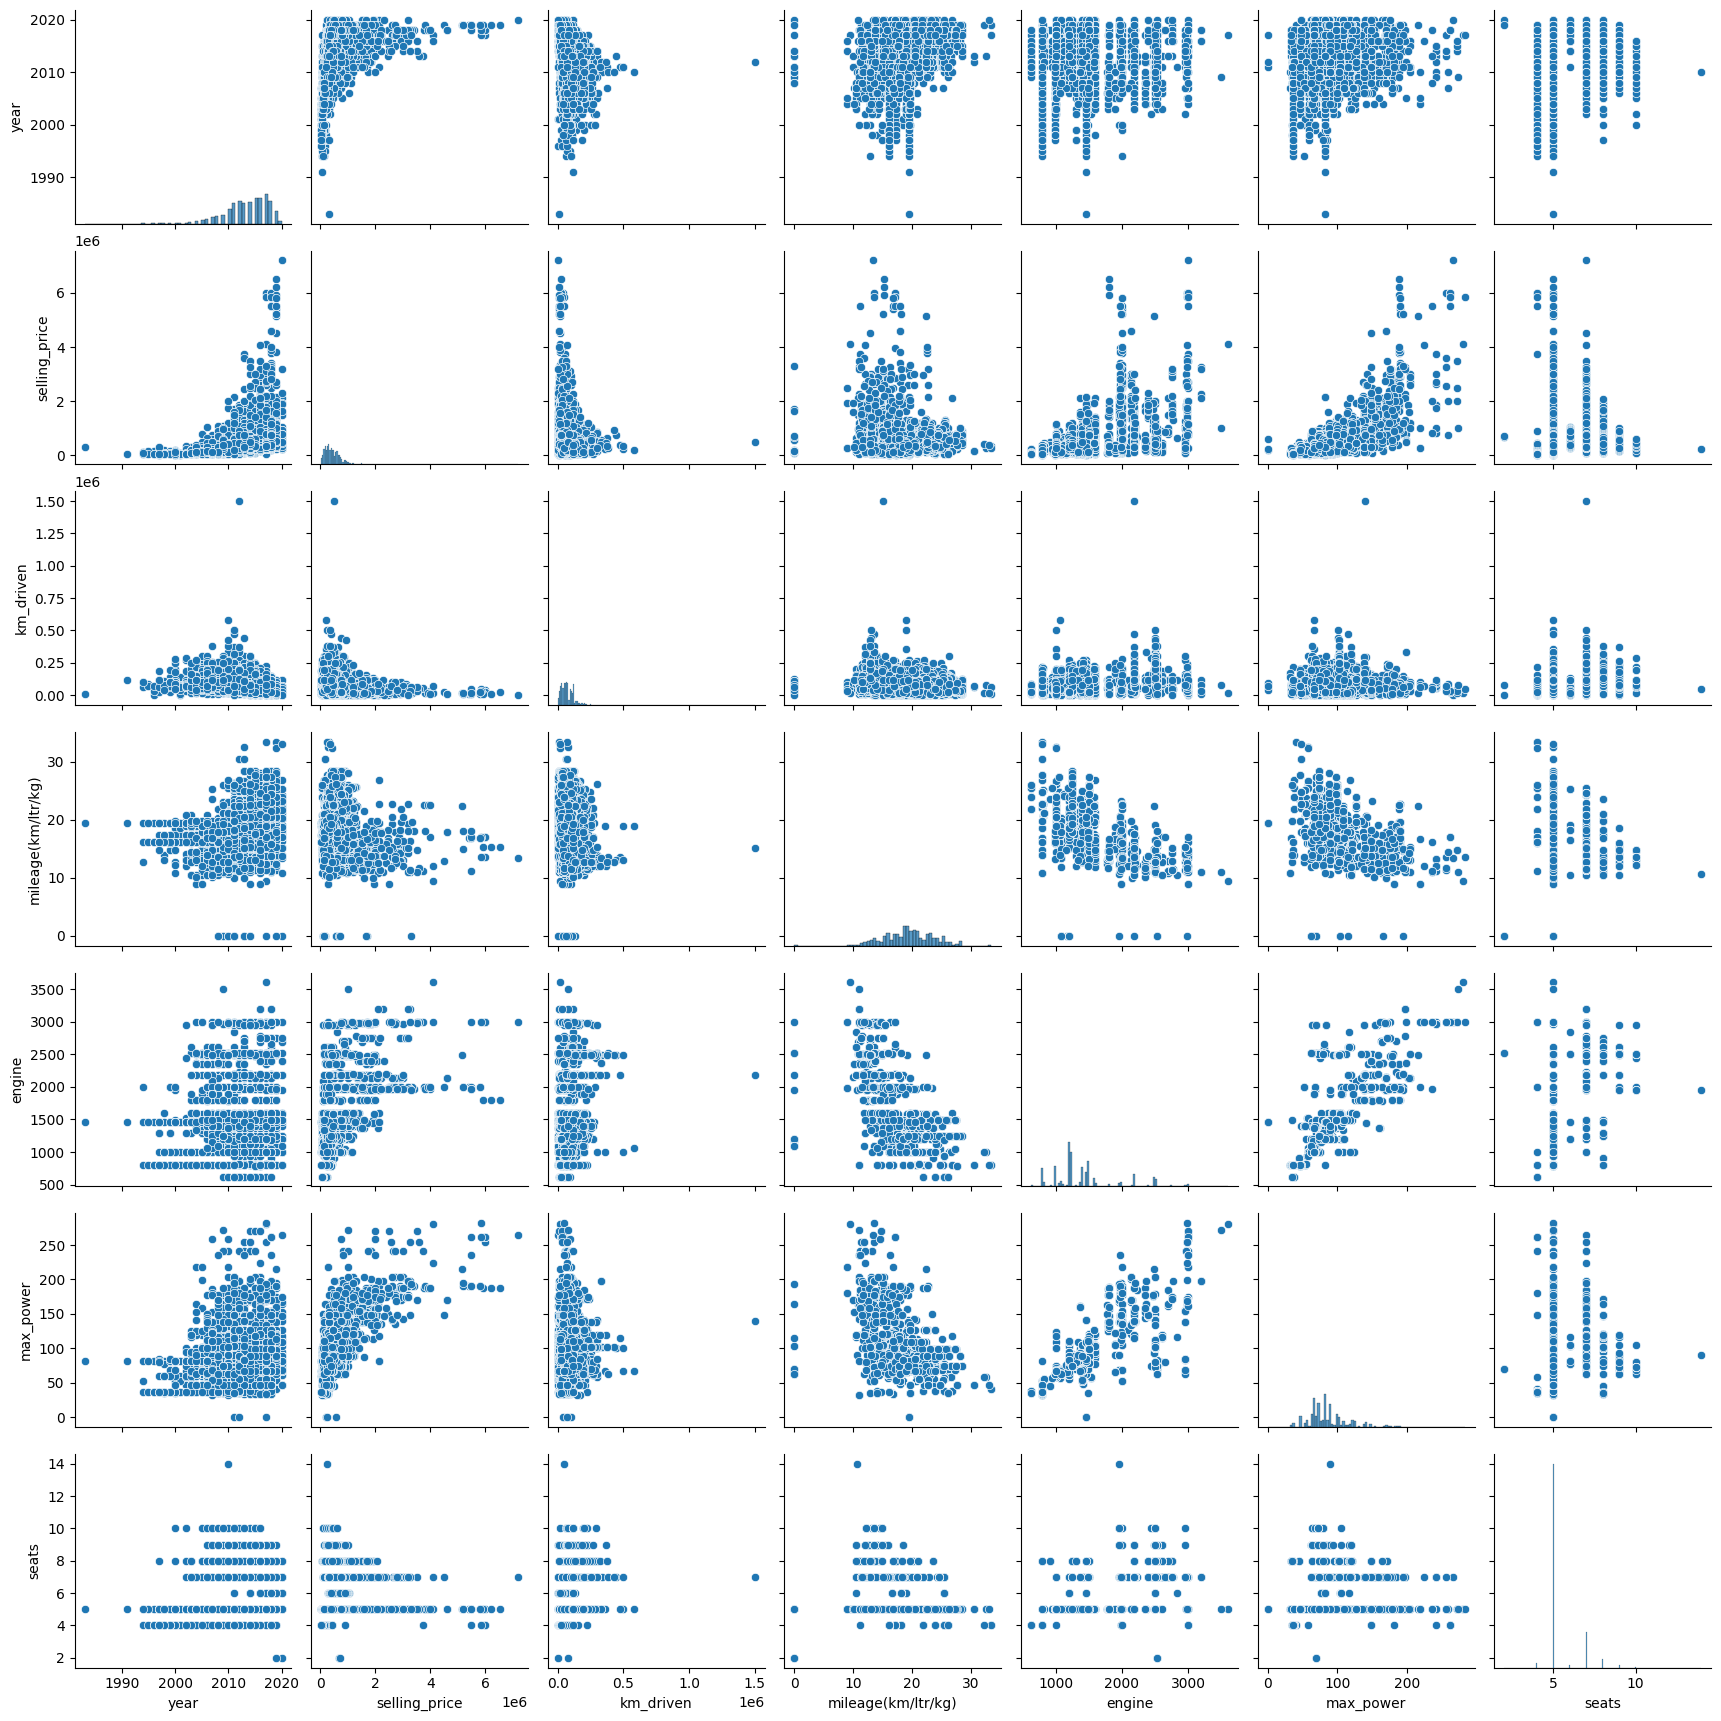

In [30]:
sns.pairplot(df)
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x_en, y, test_size=0.2, random_state=42)

In [33]:
lr = LinearRegression()
knn = KNeighborsRegressor()
svm = SVR()
dt = DecisionTreeRegressor()

In [34]:
clfs = {
    'lr' : lr,
    'knn' : knn,
    'svm' : svm,
    'dt' : dt
}

In [35]:
def evaluate_model(clf, x_train, x_test, y_train, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(y_test)

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy score: {accuracy*100:.2f}")

    # mse
    mse = mean_squared_error(y_test, y_pred)
    print(f"mse : {mse*100:.2f}")

    # mae
    mae = mean_absolute_error(y_test, y_pred)
    print(f"mae : {mae*100:.2f}")

In [36]:
for name, clf in clfs.items():
    print(name)
    evaluate_model(clf, x_train, x_test, y_train, y_test)

lr


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
x.isnull().sum()

In [ ]:
y_train.shape

In [ ]:
type(x_en)